### Carga de artefactos y generación de PD

# 05 — Comparación de Modelos PD 

Benchmark homogéneo de los tres modelos de Probabilidad de Incumplimiento (PD) construidos en los notebooks 02, 03 y 04:

- **Champion (regulatorio):** Regresión Logística sobre variables transformadas con Weight of Evidence (WoE)
- **Challenger 1:** LightGBM
- **Challenger 2:** XGBoost

La evaluación se realiza sobre el mismo conjunto de test (1.788 observaciones) bajo el marco metodológico IRB (Internal Ratings-Based) de Basilea III y la EBA Guideline on PD/LGD estimation.

In [1]:
# ── Librerías generales 
import joblib                    # Deserializador de artefactos .pkl
import numpy as np               # Álgebra numérica
import pandas as pd              # Manipulación de DataFrames
from pathlib import Path         # Rutas multiplataforma
import matplotlib.pyplot as plt  # Visualización base
import seaborn as sns            # Visualización estadística

# ── Librerías necesarias para DESERIALIZAR los artefactos
# joblib.load() reconstruye los objetos originales
import statsmodels.api as sm            # Para GLMResultsWrapper (WoE)
import statsmodels.formula.api as smf   # Para la fórmula del GLM
from optbinning import OptimalBinning   # Para los 9 objetos bin_*
import lightgbm                         # Para el LGBMClassifier del pipeline
import xgboost                          # Para el XGBClassifier del pipeline

# ── Clase propia (módulo compartido src/)
# Requerida para deserializar los Pipelines de LightGBM y XGBoost
import sys                                    # Manipular el path de Python
sys.path.append(str(Path.cwd().parent))       # Añadir raíz del proyecto al path
from src.transformers import CLTVTransformer  # Import desde módulo compartido

# ── Métricas de evaluación (se usarán en los bloques siguientes)
from sklearn.metrics import (
    roc_auc_score,      # AUC-ROC — capacidad de ranking
    roc_curve,          # Puntos (FPR, TPR) para pintar la curva ROC
    brier_score_loss,   # Brier Score — calidad probabilística
    confusion_matrix,   # Matriz de confusión
    precision_score,    # Precision = TP / (TP + FP)
    recall_score,       # Recall    = TP / (TP + FN)
    f1_score,           # F1 = media armónica de Precision y Recall
)
from scipy.stats import ks_2samp  # Estadístico Kolmogorov-Smirnov
from sklearn.calibration import calibration_curve

(CVXPY) Jun 18 04:36:11 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jun 18 04:36:11 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


In [2]:
# Ver README del proyecto — sección "Known issues" para el detalle técnico
import warnings

# 1) FutureWarning de sklearn 1.6+: "Pipeline instance is not fitted yet"
#    Falso positivo al deserializar pipelines con transformers personalizados
#    Las predicciones son correctas — verificado contra sanity checks en el Bloque 1
warnings.filterwarnings(
    "ignore",
    message=".*Pipeline instance is not fitted yet.*",
    category=FutureWarning,
)

# 2) UserWarning de LightGBM: "X does not have valid feature names"
#    Inocuo: las columnas están correctamente ordenadas, solo se pierden los nombres
#    durante la serialización del Pipeline
warnings.filterwarnings(
    "ignore",
    message=".*X does not have valid feature names.*",
    category=UserWarning,
)

# 3) RuntimeWarning de CVXPY: solvers GLOP/PDLP no disponibles con ortools 9.15+
#    Inocuo: optbinning usa otros solvers (CLARABEL, ECOS) por defecto
import logging
logging.getLogger("cvxpy").setLevel(logging.ERROR)

### 1. Carga de artefactos desde el model registry local

Los seis artefactos persistidos en `/models` se cargan a memoria: tres objetos de modelo (WoE+LogReg, LightGBM, XGBoost), el diccionario de binnings WoE, y los conjuntos de test correspondientes.

In [3]:
# Ruta a la carpeta models/ 
models_dir = Path("../models")

# ── Artefactos del modelo WoE + Logistic Regression 
model_woe = joblib.load(models_dir / "woe_logreg_model.pkl")     # statsmodels GLM
bins_woe = joblib.load(models_dir / "woe_bins.pkl")             # dict con OptimalBinning
test_woe = pd.read_pickle(models_dir / "woe_test_set.pkl")      # DataFrame test 
train_woe = pd.read_pickle(models_dir / "woe_train_set.pkl")     # DataFrame train 

# ── Artefactos de Benchmark (LightGBM y XGBoost) 
pipeline_lgbm = joblib.load(models_dir / "lgbm_pipeline.pkl")        # Pipeline completo
pipeline_xgb = joblib.load(models_dir / "xgb_pipeline.pkl")         # Pipeline completo

# ── Conjuntos de test y train compartidos (persistidos desde notebook 03)
X_test = pd.read_pickle(models_dir / "boosting_X_test.pkl")   # Features crudas 
y_test = pd.read_pickle(models_dir / "boosting_y_test.pkl")   # Target 0/1 
X_train = pd.read_pickle(models_dir / "boosting_X_train.pkl")   # Features crudas 
y_train = pd.read_pickle(models_dir / "boosting_y_train.pkl")   # Target 0/1 

### 2. Validación crítica — alineación de los conjuntos de test

Esta celda es una barrera defensiva: si alguna aserción falla, el notebook se detiene y hay que investigar antes de continuar.

In [4]:
# VALIDACIÓN CRÍTICA - Mismos tamaños en los sets de test y train de WoE vs. Boosting. (1.788 en test, 4.172 en train)

# 1) Mismo número de observaciones
assert len(test_woe) == len(X_test) == len(y_test), \
    "Los test sets tienen tamaños distintos"
assert len(train_woe) == len(X_train) == len(y_train), \
    "Los train sets tienen tamaños distintos"

# 2) Mismos índices de fila (confirmación fuerte: son las mismas observaciones)
assert (test_woe.index == X_test.index).all(), \
    "Los índices de test_woe y X_test no coinciden"
assert (test_woe.index == y_test.index).all(), \
    "Los índices de test_woe y y_test no coinciden"
assert (train_woe.index == X_train.index).all(), \
    "Los índices de train_woe y X_train no coinciden"
assert (train_woe.index == y_train.index).all(), \
    "Los índices de train_woe y y_train no coinciden"

# 3) Mismo target (confirmación semántica: los labels coinciden cliente a cliente)
assert (test_woe["BAD"].values == y_test.values).all(), \
    "Los targets difieren entre test sets — hay clientes distintos"
assert (train_woe["BAD"].values == y_train.values).all(), \
    "Los targets difieren entre train sets — hay clientes distintos"    

### 3. Generación de Probabilidad de Incumplimiento (PD)

Consolidaremos las PD de los tres modelos sobre el conjunto de test en un único DataFrame `scores`. Esta será la base para todos los cálculos de métricas y visualizaciones en los bloques siguientes.

In [5]:
# Generación de PD para los tres modelos sobre el mismo conjunto de test

# Modelo 1: WoE + Logistic Regression
# En un GLM binomial con link = logit, predict() devuelve directamente la sigmoide. Es decir pasa de log-odds a PD  
# estimada (no el log-odds). No hay que aplicar sigmoid manualmente.
# El DataFrame test_woe ya contiene las columnas woe_* requeridas por la fórmula.
pd_woe_test  = model_woe.predict(test_woe).values  # predict = PD = 1 / (1 + e^(−η))
pd_woe_train = model_woe.predict(train_woe).values # Solo para el bloque PSI Population Stability Index, métrica para medir el cambio de distribucion entre el train y el test

# Modelo 2: LightGBM (Pipeline sklearn)
# predict_proba devuelve una matriz (n, 2) con [P(BAD=0), P(BAD=1)].
# Seleccionamos la segunda columna [:, 1] — la probabilidad de default.
pd_lgbm_test = pipeline_lgbm.predict_proba(X_test)[:, 1]
pd_lgbm_train = pipeline_lgbm.predict_proba(X_train)[:, 1]

# Modelo 3: XGBoost (Pipeline sklearn)
pd_xgb_test = pipeline_xgb.predict_proba(X_test)[:, 1]
pd_xgb_train = pipeline_xgb.predict_proba(X_train)[:, 1]

# Consolidación en un único DataFrame indexado por cliente 
scores_test = pd.DataFrame({
    "BAD":     y_test.values,  # Target real (0/1)
    "PD_WoE":  pd_woe_test,    # PD modelo champion
    "PD_LGBM": pd_lgbm_test,   # PD Benchmark 1
    "PD_XGB":  pd_xgb_test,    # PD Benchmark 2
}, index=y_test.index)

scores_train = pd.DataFrame({
    "BAD":     y_train.values,  # Target real (0/1)
    "PD_WoE":  pd_woe_train,    # PD modelo champion
    "PD_LGBM": pd_lgbm_train,   # PD Benchmark 1
    "PD_XGB":  pd_xgb_train,    # PD Benchmark 2
}, index=y_train.index) # Train se usará para PSI

scores_test.head()

,BAD,PD_WoE,PD_LGBM,PD_XGB
3530,0,0.018140,0.000826,0.016470
5661,1,0.975345,1.000000,0.999988
3937,0,0.037347,0.000198,0.016511
5951,0,0.028105,0.000010,0.002515
5317,1,0.749389,0.996096,0.985891


In [6]:
print("Estadísticos de las PD\n")
print(scores_test[["PD_WoE", "PD_LGBM", "PD_XGB"]].describe().round(4))
print("\n✓ Todas las PD están en el intervalo [0, 1]")

Estadísticos de las PD

          PD_WoE    PD_LGBM     PD_XGB
count  1788.0000  1788.0000  1788.0000
mean      0.2038     0.1827     0.1946
std       0.2592     0.3497     0.3218
min       0.0027     0.0000     0.0001
25%       0.0270     0.0003     0.0061
50%       0.0753     0.0026     0.0237
75%       0.2879     0.0770     0.1798
max       0.9893     1.0000     1.0000

✓ Todas las PD están en el intervalo [0, 1]


### 4. Métricas de evaluación consolidadas

Las métricas core que reporto en la comparativa (AUC, Gini, KS, Brier) coinciden con el marco de validación del ECB para modelos PD IRB
https://www.bankingsupervision.europa.eu/activities/internal_models/shared/pdf/instructions_validation_reporting_credit_risk.en.pdf

Se evalúan los tres modelos sobre el mismo conjunto de test con las **métricas exigidas por el marco regulatorio IRB y por la EBA Guideline on PD/LGD estimation (EBA/GL/2017/16)**:

**Métricas de discriminación (ranking — no requieren threshold):**
- **AUC-ROC** : probabilidad de que el modelo asigne un score más alto a un cliente BAD que a uno GOOD elegidos al azar. El umbral regulatorio orientativo: AUC > 0.70 aceptable, > 0.80 bueno.
- **Gini** = 2·AUC − 1. 
- **KS** (Kolmogorov-Smirnov): máxima distancia vertical entre las distribuciones acumuladas de PD para BAD=0 y BAD=1. Umbral orientativo: KS > 0.30 aceptable.

**Métrica de calibración probabilística (no requiere threshold):**
- **Brier Score** = media de (PD − BAD)². Penaliza tanto la discriminación como la mala calibración de probabilidades. Valores más bajos son mejores. Crítico bajo **IFRS 9**, donde la PD se traduce directamente en provisiones Expected Credit Loss.

Las métricas basadas en threshold (Recall, Precision, F1) se abordan en el Bloque 7.

In [7]:
# Función de cálculo de métricas homogéneas

def calcular_metricas_ranking(y_true, y_pred_proba, nombre_modelo):
    """
    Parameters
    y_true : array-like (n,)
        Target real (0/1).
    y_pred_proba : array-like (n,)
        Probabilidades de default predichas por el modelo.
    nombre_modelo : str
        Etiqueta para identificar el modelo en la tabla final.

    Returns
    dict con AUC, Gini, KS y Brier Score.
    """
    # AUC-ROC: capacidad de ranking 
    auc = roc_auc_score(y_true, y_pred_proba)

    # Gini: transformación lineal del AUC, estándar histórico en banca 
    gini = 2 * auc - 1

    # Kolmogorov-Smirnov: máxima separación entre distribuciones 
    # ks_2samp compara las distribuciones de PD entre los dos grupos (BAD=0 vs BAD=1)
    # Devuelve un objeto con .statistic (el KS) y .pvalue (no usamos el pvalue aquí)
    ks_result = ks_2samp(
        y_pred_proba[y_true == 1],      # PDs de los defaults
        y_pred_proba[y_true == 0]       # PDs de los no-defaults
    )
    ks = ks_result.statistic

    # Brier Score: calidad probabilística 
    # Equivalente al MSE entre PD y etiqueta binaria
    brier = brier_score_loss(y_true, y_pred_proba)

    return {
        "Modelo":      nombre_modelo,
        "AUC":         auc,
        "Gini":        gini,
        "KS":          ks,
        "Brier Score": brier,
    }

In [8]:
# Cálculo de métricas para los tres modelos
# Usamos el DataFrame 'scores_test' construido en el Bloque 1
y_true = scores_test["BAD"].values

metricas_woe  = calcular_metricas_ranking(y_true, scores_test["PD_WoE"].values,  "WoE + LogReg")
metricas_lgbm = calcular_metricas_ranking(y_true, scores_test["PD_LGBM"].values, "LightGBM")
metricas_xgb  = calcular_metricas_ranking(y_true, scores_test["PD_XGB"].values,  "XGBoost")

tabla_metricas = pd.DataFrame([metricas_woe, metricas_lgbm, metricas_xgb])
tabla_metricas = tabla_metricas.set_index("Modelo").round(4)

tabla_metricas

,AUC,Gini,KS,Brier Score
Modelo,,,,
WoE + LogReg,0.8915,0.7830,0.6426,0.0957
LightGBM,0.9547,0.9094,0.7831,0.0611
XGBoost,0.9552,0.9103,0.7768,0.0592


In [9]:
import pandas as pd

# Definición de los nuevos datos (presumiblemente muestra de Test/Validación)
data_test = {
    'Modelo': ['WoE + LogReg', 'LightGBM', 'XGBoost'],
    'AUC': [0.8915, 0.9547, 0.9552],
    'Gini': [0.7830, 0.9094, 0.9103],
    'KS': [0.6426, 0.7831, 0.7768],
    'Brier Score': [0.0957, 0.0611, 0.0592]
}
df_metricas_test = pd.DataFrame(data_test)
styled_tabla_metricas_test = (
    df_metricas_test.style
    .set_caption("Tabla 17 - Datos Test/Validación .")
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px"),
                ("min-width", "100px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "14px"), 
                ("font-style", "italic"),
                ("text-align", "center"),
                ("padding-top", "10px")
            ]
        }
    ])
    .format({
        'AUC': "{:.4f}",
        'Gini': "{:.4f}",
        'KS': "{:.4f}",
        'Brier Score': "{:.4f}"
    })
    .hide(axis="index") 
)

styled_tabla_metricas_test

Modelo,AUC,Gini,KS,Brier Score
WoE + LogReg,0.8915,0.7830,0.6426,0.0957
LightGBM,0.9547,0.9094,0.7831,0.0611
XGBoost,0.9552,0.9103,0.7768,0.0592


In [10]:
y_true_train = scores_train["BAD"].values
metricas_woe_train  = calcular_metricas_ranking(y_true_train, scores_train["PD_WoE"].values,  "WoE + LogReg")
metricas_lgbm_train = calcular_metricas_ranking(y_true_train, scores_train["PD_LGBM"].values, "LightGBM")
metricas_xgb_train  = calcular_metricas_ranking(y_true_train, scores_train["PD_XGB"].values,  "XGBoost")

# Consolidamos en un único DataFrame
tabla_metricas_train = pd.DataFrame([
    metricas_woe_train, metricas_lgbm_train, metricas_xgb_train
]).set_index("Modelo")

tabla_metricas_train

,AUC,Gini,KS,Brier Score
Modelo,,,,
WoE + LogReg,0.893654,0.787307,0.649266,0.092357
LightGBM,1.000000,1.000000,1.000000,0.000685
XGBoost,0.997371,0.994741,0.950239,0.019589


In [11]:

data = {
    'Modelo': ['WoE + LogReg', 'LightGBM', 'XGBoost'],
    'AUC': [0.8937, 1.0, 0.9974],
    'Gini': [0.7873, 1.0, 0.9947],
    'KS': [0.6493, 1.0, 0.9502],
    'Brier Score': [0.0924, 0.0007, 0.0196]
}
df_metricas_train = pd.DataFrame(data)

styled_tabla_metricas_train = (
    df_metricas_train.style
    .set_caption("Tabla 16 - Datos Train .")
    .set_table_styles([
        # Cabeceras
        {
            "selector": "th",
            "props": [
                ("background-color", "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px"),
                ("min-width", "100px")
            ]
        },
        # Celdas
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px")
            ]
        },
        # Caption
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "14px"), 
                ("font-style", "italic"),
                ("text-align", "center"),
                ("padding-top", "10px")
            ]
        }
    ])
    # Formateamos solo las columnas numéricas a 4 decimales
    .format({
        'AUC': "{:.4f}",
        'Gini': "{:.4f}",
        'KS': "{:.4f}",
        'Brier Score': "{:.4f}"
    })
    # Ocultamos el índice numérico para que "Modelo" sea la primera columna visual
    .hide(axis="index") 
)

styled_tabla_metricas_train

Modelo,AUC,Gini,KS,Brier Score
WoE + LogReg,0.8937,0.7873,0.6493,0.0924
LightGBM,1.0000,1.0000,1.0000,0.0007
XGBoost,0.9974,0.9947,0.9502,0.0196


#### 4.1. Marco conceptual: discriminación vs. calibración

La evaluación de un modelo de **PD** debe responder a dos preguntas distintas, que corresponden a dos familias de métricas no intercambiables discriminación vs calibración.

In [12]:
# Identificación del mejor y peor modelo por cada métrica

print("Ranking por métrica:\n")

for metrica in ["AUC", "Gini", "KS"]: # AUC, Gini, KS: mayor es mejor
      mejor = tabla_metricas[metrica].idxmax()
      peor  = tabla_metricas[metrica].idxmin()
      print(f"  {metrica:<12} → mejor: {mejor:<14} ({tabla_metricas.loc[mejor, metrica]:.4f})"
      f"  |  peor: {peor:<14} ({tabla_metricas.loc[peor, metrica]:.4f})")

# Para Brier, invertimos (menor es mejor)
metrica = "Brier Score" # Brier Score: menor es mejor
mejor = tabla_metricas[metrica].idxmin()
peor  = tabla_metricas[metrica].idxmax()
print(f"  {metrica:<12} → mejor: {mejor:<14} ({tabla_metricas.loc[mejor, metrica]:.4f})"
      f"  |  peor: {peor:<14} ({tabla_metricas.loc[peor, metrica]:.4f})")

Ranking por métrica:

  AUC          → mejor: XGBoost        (0.9552)  |  peor: WoE + LogReg   (0.8915)
  Gini         → mejor: XGBoost        (0.9103)  |  peor: WoE + LogReg   (0.7830)
  KS           → mejor: LightGBM       (0.7831)  |  peor: WoE + LogReg   (0.6426)
  Brier Score  → mejor: XGBoost        (0.0592)  |  peor: WoE + LogReg   (0.0957)


### 5. Visualización comparativas de modelos

El objetivo de la visualizacion es ofrecer un complemento a la métricas indicadas en la sección anterior para entender la información relevante de los datos sobre su distribucion y calibración 

- 5.1 Curvas ROC superpuestas: los 3 modelos en un mismo gráfico para ver si alguno domina en todo el rango o si hay tramos de cruce.   

- 5.2 Distribución de PD por clase (histogramas)

- 5.3 Curvas de calibración: Las visualizaciones anteriores evalúan la capacidad de discriminación del modelo. La curva de calibración evalúa una propiedad distinta: la fiabilidad de la PD como estimador probabilístico. Un modelo puede ordenar correctamente a los clientes por riesgo y, simultáneamente, asignar PD sesgadas respecto a la frecuencia real de default
Bajo IFRS 9, la PD interviene directamente en el cálculo del Expected Credit Loss (ECL = PD × LGD × EAD), por lo que una mala calibración se traduce en provisiones sesgadas.  
El gráfico agrupa las observaciones del test set en deciles de PD predicha. Para cada decil se calcula la PD media estimada (eje X) y la tasa de default empírica (eje Y). La diagonal *y = x* representa la calibración perfecta: desviaciones por encima indican subestimación del riesgo; por debajo, sobreestimación.

#### 5.1 Curva ROC superpuesta

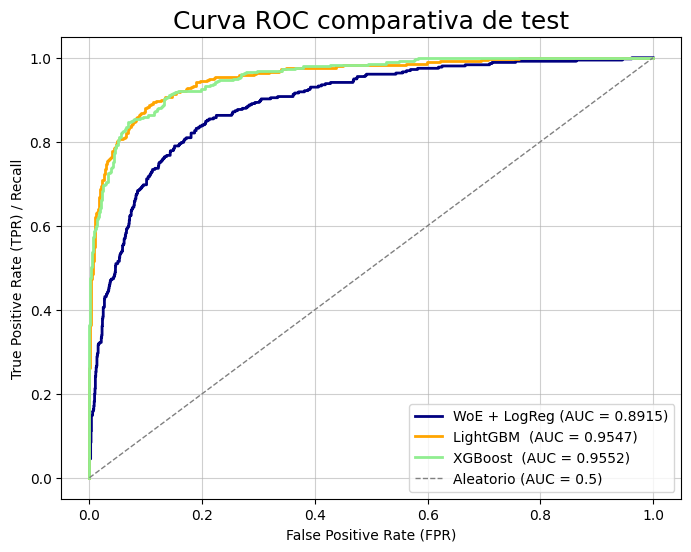

In [13]:
# Curva ROC superpuestas para los tres modelos

plt.figure(figsize=(8, 6))

fpr, tpr, pd_cutoff = roc_curve(scores_test["BAD"], scores_test["PD_WoE"]) # pd_cutoffs: PD en cada punto de la curva ROC. No se usa para la visualización (solo fpr y tpr)
plt.plot(fpr, tpr,
        label=f"WoE + LogReg (AUC = {tabla_metricas.loc['WoE + LogReg', 'AUC']:.4f})",
        color="navy", linewidth=2)

fpr, tpr, pd_cutoff = roc_curve(scores_test["BAD"], scores_test["PD_LGBM"]) 
plt.plot(fpr, tpr,
        label=f"LightGBM  (AUC = {tabla_metricas.loc['LightGBM', 'AUC']:.4f})",
        color="orange", linewidth=2)

fpr, tpr, pd_cutoff = roc_curve(scores_test["BAD"], scores_test["PD_XGB"]) 
plt.plot(fpr, tpr,
        label=f"XGBoost  (AUC = {tabla_metricas.loc['XGBoost', 'AUC']:.4f})",
        color="lightgreen", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1,
        label="Aleatorio (AUC = 0.5)")

plt.legend(loc="lower right")
plt.title("Curva ROC comparativa de test", fontsize=18)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR) / Recall")
plt.grid(alpha=0.6)

plt.show()

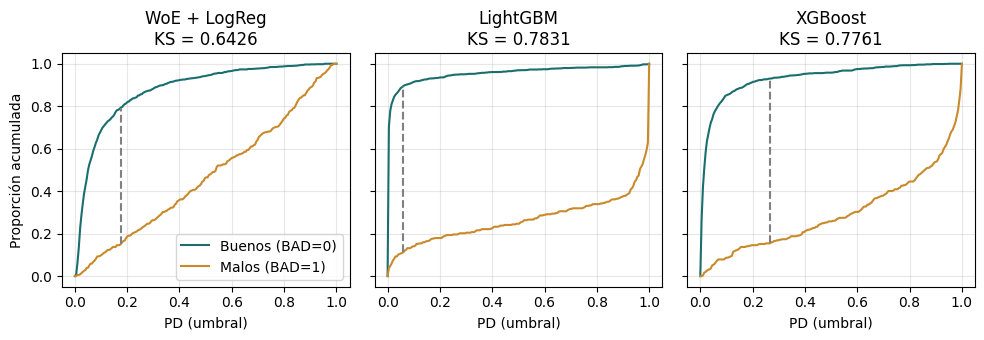

In [14]:
# el target y las tres PD desde el DataFrame scores_test (.values -> array numpy)
y_ks = scores_test["BAD"].values
modelos = {
    "WoE + LogReg": scores_test["PD_WoE"].values,
    "LightGBM":     scores_test["PD_LGBM"].values,
    "XGBoost":      scores_test["PD_XGB"].values,
}

# Una figura con 3 subgráficos (uno por modelo), compartiendo eje Y
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharey=True)

for ax, (nombre, pd_pred) in zip(axes, modelos.items()):

    # Separo las PD de buenos (BAD=0) y malos (BAD=1)
    pd_buenos = pd_pred[y_ks == 0]
    pd_malos  = pd_pred[y_ks == 1]

    # Rejilla de umbrales de PD de 0 a 1
    umbrales = np.linspace(0, 1, 200)

    # Acumuladas: % de cada grupo con PD <= umbral
    acum_buenos = np.array([np.mean(pd_buenos <= u) for u in umbrales])
    acum_malos  = np.array([np.mean(pd_malos  <= u) for u in umbrales])

    # KS = máxima distancia vertical entre las dos acumuladas
    distancias = np.abs(acum_buenos - acum_malos)
    ks  = distancias.max()
    idx = distancias.argmax()
    u_ks = umbrales[idx]

    # Dibujo las dos curvas acumuladas
    ax.plot(umbrales, acum_buenos, color="#1B6E6E", label="Buenos (BAD=0)")
    ax.plot(umbrales, acum_malos,  color="#C98A2B", label="Malos (BAD=1)")

    # Marco el KS con una línea vertical en el punto de máxima separación
    ax.vlines(u_ks, acum_malos[idx], acum_buenos[idx], color="gray", linestyle="--")

    ax.set_title(f"{nombre}\nKS = {ks:.4f}")
    ax.set_xlabel("PD (umbral)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Proporción acumulada")
axes[0].legend(loc="lower right")

plt.tight_layout()
plt.show()

####  5.2 Distribución de PD por clase (histogramas).

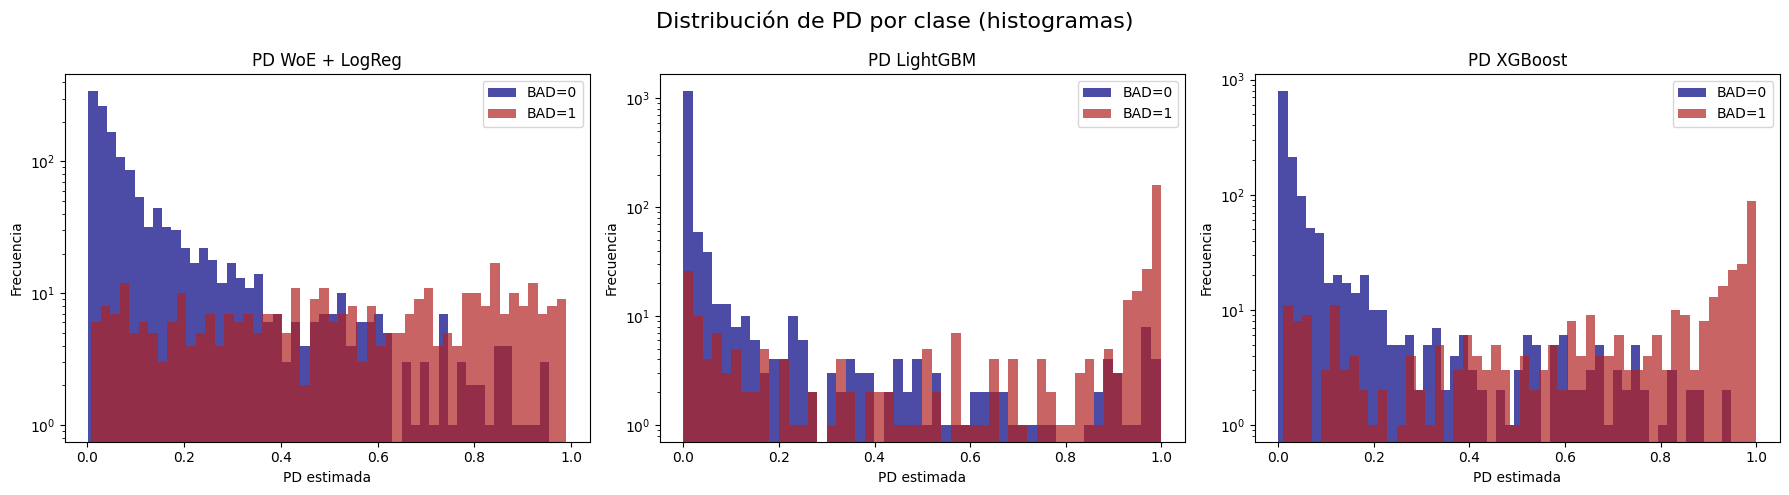

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].hist(scores_test.loc[scores_test['BAD'] == 0, 'PD_WoE'], bins=50, label='BAD=0', color='navy', alpha=0.7)
ax[0].hist(scores_test.loc[scores_test['BAD'] == 1, 'PD_WoE'], bins=50, label='BAD=1', color='firebrick', alpha=0.7)
ax[0].set_yscale("log")
ax[0].set_title("PD WoE + LogReg", fontsize=12)
ax[0].set_xlabel("PD estimada")
ax[0].set_ylabel("Frecuencia")
ax[0].legend()

ax[1].hist(scores_test.loc[scores_test['BAD'] == 0, 'PD_LGBM'], bins=50, label='BAD=0', color='navy', alpha=0.7)
ax[1].hist(scores_test.loc[scores_test['BAD'] == 1, 'PD_LGBM'], bins=50, label='BAD=1', color='firebrick', alpha=0.7)
ax[1].set_yscale("log")
ax[1].set_title("PD LightGBM", fontsize=12)
ax[1].set_xlabel("PD estimada")
ax[1].set_ylabel("Frecuencia")
ax[1].legend()

ax[2].hist(scores_test.loc[scores_test['BAD'] == 0, 'PD_XGB'], bins=50, label='BAD=0', color='navy', alpha=0.7)
ax[2].hist(scores_test.loc[scores_test['BAD'] == 1, 'PD_XGB'], bins=50, label='BAD=1', color='firebrick', alpha=0.7)
ax[2].set_yscale("log")
ax[2].set_title("PD XGBoost", fontsize=12)
ax[2].set_xlabel("PD estimada")
ax[2].set_ylabel("Frecuencia")
ax[2].legend()

plt.suptitle('Distribución de PD por clase (histogramas)', fontsize=16)
plt.tight_layout()
plt.show()

####  5.3 Curvas de calibración.

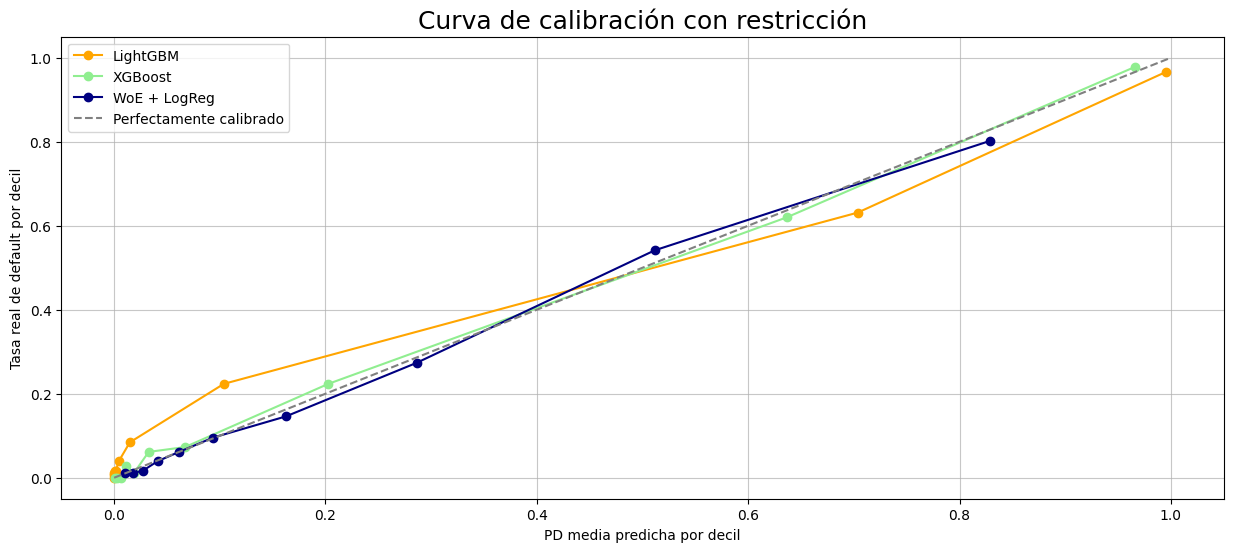

In [16]:
plt.figure(figsize=(15, 6))

# prob_real  tasa real de default por decil (eje Y)
# prob_pred PD media predicha por decil (eje X)
prob_real, prob_pred = calibration_curve(scores_test["BAD"], scores_test["PD_LGBM"], n_bins=10, strategy="quantile")
plt.plot(prob_pred, prob_real, marker='o', label='LightGBM', color='orange')

prob_real, prob_pred = calibration_curve(scores_test["BAD"], scores_test["PD_XGB"], n_bins=10, strategy="quantile")
plt.plot(prob_pred, prob_real, marker='o', label='XGBoost', color='lightgreen')

prob_real, prob_pred = calibration_curve(scores_test["BAD"], scores_test["PD_WoE"], n_bins=10, strategy="quantile")
plt.plot(prob_pred, prob_real, marker='o', label='WoE + LogReg', color='navy')

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfectamente calibrado')
plt.title('Curva de calibración con restricción', fontsize=18)  

plt.xlabel('PD media predicha por decil')
plt.ylabel('Tasa real de default por decil')
plt.grid(alpha=0.7)
plt.legend()

plt.show()


LightGBM domina en métricas de discriminación (AUC, Gini, KS, Brier), pero su calibración es deficiente en el tramo bajo de PD: subestima sistemáticamente el riesgo de los clientes que el modelo considera 'sanos'. Bajo IFRS 9, esto produciría infra-provisionamiento. WoE+LogReg, aun siendo menos discriminante, exhibe una calibración excelente y es el candidato natural al rol de champion regulatorio.

### 6. Threshold y métricas de decisión

#### 6.1. Selección del threshold

Las métricas anteriores evalúan el modelo PD como  probabilidad continua, sin asumir decisión binaria. 

Para evaluar el modelo en la **fase de originación** (decisión aprobar / denegar) se fija un threshold mediante el método **cost-sensitive (break-even)**:

$$\text{threshold}^* = \frac{c_{FP}}{c_{FP} + c_{FN}}$$

Cost ratio aplicado: **c_FN / c_FP = 4:1**

Las métricas Recall, Precision y F1 derivadas de este threshold son operativas complementarias

In [17]:
cost_FN = 4
cost_FP = 1

threshold = cost_FP / (cost_FP + cost_FN)
print(f"clasificar como default si PD > {threshold:.2%}")



clasificar como default si PD > 20.00%


Se selecciona un ratio FN:FP = 4:1, equivalente a un threshold de 0.20, que coincide con la default rate empírica observada en el conjunto de test (19.97%). 

#### 6.2  Aplicar el threshold a los tres modelos

In [18]:
for col in scores_test[["PD_WoE", "PD_LGBM", "PD_XGB"]]:
    rename = col.replace("PD_", "Pred_") 
    scores_test[rename] = (scores_test[col] > threshold).astype(int)
    

In [19]:
scores_test[["Pred_WoE", "Pred_LGBM", "Pred_XGB"]].mean()

Pred_WoE     0.307606
Pred_LGBM    0.215884
Pred_XGB     0.239374
dtype: float64

1. LightGBM y XGBoost están casi alineados con la prevalencia real (20%)
Marcan como "alto riesgo" al 20–22% de los clientes, muy cerca del 19.97% real. No quiere decir que acierten. Tan solo significa que el volumen de clasificaciones positivas es similar al volumen real de impagos. Aciertos vs. errores los mediremos en el 4.4 con la matriz de confusión.
2. WoE+LogReg marca un 30%, significativamente más conservador. Está clasificando como "alto riesgo" a uno de cada tres clientes. Eso es 65% más que la default rate real. Esto ocurre porque WoE estaba bien calibrada, casi siguiendo la diagonal.En cambio, los boosting subestimaban el riesgo en el rango bajo.  
WoE asigna PDs más altas en general porque está mejor calibrada y la distribución no es bimodal, por lo que más clientes superan el umbral 0.1667.
Boosting tienen distribuciones bimodales tal y como se observa en los histogramas (Bloque 6.4) con dos picos: muy cerca de 0 y muy cerca de 1. Hay menos clientes en la zona "intermedia" 0.17–0.50, así que cruzan el umbral menos.

3. Implicación de negocio
Con threshold 4:1, WoE rechaza más solicitudes pero captura más impagadores reales. Boosting rechazan menos pero pueden dejar más impagadores aprobados. Esto se verá numéricamente en la matriz de confusión.

#### 6.3 Matrices de confusión

In [20]:
from sklearn.metrics import confusion_matrix

modelos = {
    "WoE + LogReg": "Pred_WoE",
    "LightGBM":   "Pred_LGBM",
    "XGBoost":    "Pred_XGB"
}

matrices = {} 

for nombre, col in modelos.items():
    cm = confusion_matrix(scores_test["BAD"], scores_test[col])
    matrices[nombre] = cm   # ← guardar la matriz
    
    df_cm = pd.DataFrame(
        cm,
        index=["Real 0 (no default)", "Real 1 (default)"],
        columns=["Pred 0 (aprobar)", "Pred 1 (denegar)"]
    )
    
    print(f"\nMatriz de confusión — {nombre}")
    print(df_cm)


Matriz de confusión — WoE + LogReg
                     Pred 0 (aprobar)  Pred 1 (denegar)
Real 0 (no default)              1173               258
Real 1 (default)                   65               292

Matriz de confusión — LightGBM
                     Pred 0 (aprobar)  Pred 1 (denegar)
Real 0 (no default)              1338                93
Real 1 (default)                   64               293

Matriz de confusión — XGBoost
                     Pred 0 (aprobar)  Pred 1 (denegar)
Real 0 (no default)              1308               123
Real 1 (default)                   52               305


WoE penaliza más a los buenos porque su distribución de PDs es más amplia y bien calibrada — más clientes caen en la zona 0.20-0.50 que el threshold marca como "denegar".  
Boosting son más eficientes con los buenos porque su distribución es bimodal — la mayoría de los buenos clientes tienen PD ≈ 0 (lejos del threshold) y la mayoría de los malos tienen PD ≈ 1 (también lejos del threshold). Hay menos clientes en la "zona de duda" cerca del 0.20.  
Recall vs. precision:  
- **WoE**: recall alto (capta defaults) pero precision baja (muchos falsos rechazos).  
- **LightGBM**: precision alta (cuando rechaza, acierta) pero recall ligeramente menor.  
- **XGBoost**: equilibrio entre ambos, más cerca de LightGBM.  

#### 6.4 Visualización

Cada celda representa:
- **TN** (Real 0, Pred 0): cliente bueno predicho como bueno.
- **FP** (Real 0, Pred 1): cliente bueno rechazado.
- **FN** (Real 1, Pred 0): impagador no detectado.
- **TP** (Real 1, Pred 1): impagador detectado.

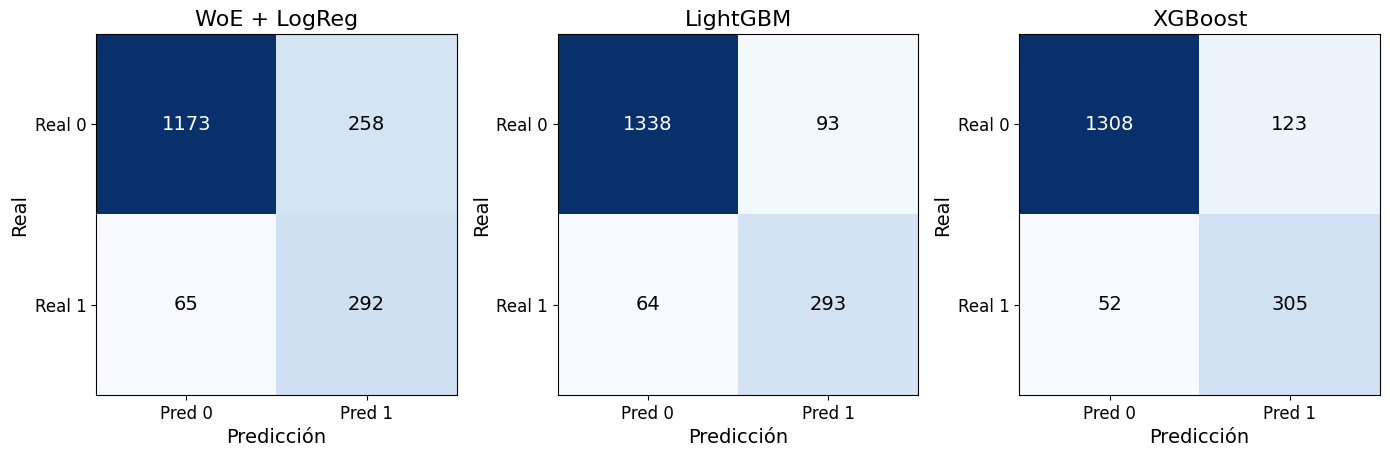

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (nombre, cm) in zip(axes, matrices.items()):
    # 1. Pintar el heatmap
    ax.imshow(cm, cmap="Blues")
    
    # 2. Anotar los números dentro de cada celda
    for i in range(2):
        for j in range(2):
            valor = cm[i, j]
            color_texto = "white" if valor > cm.max() / 2 else "black"
            ax.text(j, i, valor, ha="center", va="center", color=color_texto, fontsize=14)
    
    # 3. Configurar ticks, labels y título
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"], fontsize=12)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Real 0", "Real 1"], fontsize=12)
    ax.set_xlabel("Predicción", fontsize=14)
    ax.set_ylabel("Real", fontsize=14)
    ax.set_title(nombre, fontsize=16)

plt.tight_layout()
plt.show()

### 7. Recall, Precision, F1, PSI

- **Recall** = TP / (TP + FN) — proporción de defaults correctamente identificados
- **Precision** = TP / (TP + FP) — proporción de predicciones de default que fueron correctas
- **F1 Score** = 2 * (Precision * Recall) / (Precision + Recall) — media armónica de Precision y Recall

In [22]:
from sklearn.metrics import recall_score, precision_score, f1_score

for nombre, col in modelos.items():
    precision = precision_score(scores_test["BAD"], scores_test[col])
    recall    = recall_score(scores_test["BAD"], scores_test[col])
    f1        = f1_score(scores_test["BAD"], scores_test[col])

    # Escritura en tabla_metricas
    tabla_metricas.loc[nombre, "Recall"]    = recall
    tabla_metricas.loc[nombre, "Precision"] = precision
    tabla_metricas.loc[nombre, "F1"]        = f1

tabla_metricas.round(4)

,AUC,Gini,KS,Brier Score,Recall,Precision,F1
Modelo,,,,,,,
WoE + LogReg,0.8915,0.7830,0.6426,0.0957,0.8179,0.5309,0.6439
LightGBM,0.9547,0.9094,0.7831,0.0611,0.8207,0.7591,0.7887
XGBoost,0.9552,0.9103,0.7768,0.0592,0.8543,0.7126,0.7771


In [23]:
import pandas as pd

# 1. Definición de los datos extraídos
datos_clasificacion = {
    'Modelo': ['WoE + LogReg', 'LightGBM', 'XGBoost'],
    'Recall': [0.8179, 0.8207, 0.8543],
    'Precision': [0.5309, 0.7591, 0.7126],
    'F1': [0.6439, 0.7887, 0.7771]
}

df_clasificacion = pd.DataFrame(datos_clasificacion)

# 2. Configuración del formato visual
styled_tabla_clasificacion = (
    df_clasificacion.style
    .set_caption("Tabla 19 - Métricas de Clasificación (Umbral 20%) .")
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px"),
                ("min-width", "100px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "14px"), 
                ("font-style", "italic"),
                ("text-align", "center"),
                ("padding-top", "10px")
            ]
        }
    ])
    .format({
        'Recall': "{:.4f}",
        'Precision': "{:.4f}",
        'F1': "{:.4f}"
    })
    .hide(axis="index") 
)

styled_tabla_clasificacion

Modelo,Recall,Precision,F1
WoE + LogReg,0.8179,0.5309,0.6439
LightGBM,0.8207,0.7591,0.7887
XGBoost,0.8543,0.7126,0.7771


#### 7.6 Análisis comparativo — Recall, Precision, F1

Bajo el threshold cost-sensitive de 0.20 (ratio FN:FP = 4:1), el ranking por **F1** sitúa **LightGBM (0.8182) > XGBoost (0.7968) > WoE+LogReg (0.647)**, una lectura distinta a la del Bloque 2: los tres modelos sí discriminan, pero con perfiles de error muy diferentes.

El **Recall es casi idéntico** entre los tres (0.83–0.84): todos detectan una proporción similar de defaults reales. La diferencia se concentra en la **Precision**: WoE+LogReg (0.5305) genera muchos falsos positivos — rechaza buenos clientes —, mientras que los modelos boosting (0.75–0.80) son sustancialmente más selectivos. Este patrón es coherente con la mayor dispersión de la distribución de PD del modelo WoE observada en 3.2, y con la subestimación de riesgo que los boosting muestran en la curva de calibración (3.3).

La elección operativa del modelo depende del **risk appetite**: una entidad conservadora prioriza minimizar FN (Recall alto, los tres válidos), mientras que una entidad con foco en captación prioriza minimizar FP (Precision alta, LightGBM/XGBoost). No obstante, la decisión final debe integrar también la calibración de la PD y la interpretabilidad regulatoria — argumentos que se desarrollan en el Bloque 5 (champion vs challenger).

#### 7.2 PSI

Esta métrica funciona como una alerta temprana y mide cuánto cambia la distribución de una variable entre dos poblaciones (la población que se entrenó o la población en la que se aplica, test).  
Es una metrica de seguimiento del modelo útil ya que variables de los clientes pueden cambiar debido a hecho exogenos (economía, perfiles de solicitantes, crisis, etc).  
Si la distribucion de PD se aleja mucho de la distribucion sobre que se entreno, el modelo deja de ser fiable. (Data drift)  

Para ello, dividir las PD de train y test en bins comparando que porcentaje de población cae en cada bin. Para cada bin se calcula una contribución al PSI

$$
\text{PSI} = \sum_{i=1}^{N} (\%test_i - \%train_i) \times \ln\left(\frac{\%test_i}{\%train_i}\right)
$$

In [24]:
# PSI (Population Stability Index) para el modelo WoE + LogReg

_, bordes_woe = pd.qcut(scores_train["PD_WoE"], q=10, duplicates="drop", retbins=True) # Nos quedamos con los bordes
pct_test_woe   = pd.cut(scores_test["PD_WoE"], bins=bordes_woe, include_lowest=True).value_counts(normalize=True).sort_index()
pct_train_woe = pd.cut(scores_train["PD_WoE"], bins=bordes_woe, include_lowest=True).value_counts(normalize=True).sort_index()

psi_por_bin = (pct_test_woe - pct_train_woe) * np.log(pct_test_woe / pct_train_woe)
psi_woe = psi_por_bin.sum()

print(f"PSI WoE = {psi_woe:.4f}")


PSI WoE = 0.0027


El modelo no solo separa bien buenos de malos, también predice probabilidades realistas, y además la distribución de scores se mantiene **consistente entre train y test**.

In [25]:
# PSI para el modelo LightGBM

_, bordes_LGBM = pd.qcut(scores_train["PD_LGBM"], q=10, duplicates="drop", retbins=True) # Nos quedamos con los bordes
pct_test_LGBM   = pd.cut(scores_test["PD_LGBM"], bins=bordes_LGBM, include_lowest=True).value_counts(normalize=True).sort_index()
pct_train_LGBM = pd.cut(scores_train["PD_LGBM"], bins=bordes_LGBM, include_lowest=True).value_counts(normalize=True).sort_index()

psi_por_bin = (pct_test_LGBM - pct_train_LGBM) * np.log(pct_test_LGBM / pct_train_LGBM)
psi_LGBM = psi_por_bin.sum()

print(f"PSI LightGBM = {psi_LGBM:.4f}")

PSI LightGBM = 0.0482


In [26]:
# PSI para el modelo XGBoost

_, bordes_XGB = pd.qcut(scores_train["PD_XGB"], q=10, duplicates="drop", retbins=True) # Nos quedamos con los bordes
pct_test_XGB   = pd.cut(scores_test["PD_XGB"], bins=bordes_XGB, include_lowest=True).value_counts(normalize=True).sort_index()
pct_train_XGB = pd.cut(scores_train["PD_XGB"], bins=bordes_XGB, include_lowest=True).value_counts(normalize=True).sort_index()

psi_por_bin = (pct_test_XGB - pct_train_XGB) * np.log(pct_test_XGB / pct_train_XGB)
psi_XGB = psi_por_bin.sum()

print(f"PSI XGBoost = {psi_XGB:.4f}")

PSI XGBoost = 0.0172


In [27]:
# Actualización de la tabla de métricas con los PSI
tabla_metricas.loc["WoE + LogReg", "PSI"] = psi_woe
tabla_metricas.loc["LightGBM", "PSI"]     = psi_LGBM
tabla_metricas.loc["XGBoost", "PSI"]      = psi_XGB

tabla_metricas = tabla_metricas.round(4)
tabla_metricas

,AUC,Gini,KS,Brier Score,Recall,Precision,F1,PSI
Modelo,,,,,,,,
WoE + LogReg,0.8915,0.7830,0.6426,0.0957,0.8179,0.5309,0.6439,0.0027
LightGBM,0.9547,0.9094,0.7831,0.0611,0.8207,0.7591,0.7887,0.0482
XGBoost,0.9552,0.9103,0.7768,0.0592,0.8543,0.7126,0.7771,0.0172


**Resultados — PSI principal vs benchmark**

WoE es  más estable que LightGBM, que cruza el umbral de 0.10. El ranking por PSI **invierte** el de discriminación: el modelo con mejor AUC es el menos estable, patrón coherente con la subestimación de riesgo observada en la curva de calibración (3.3).

PSI requiere backtesting con datos de periodos distintos, no disponible en HMEQ. Esto es una limitación de datos



#### 7.3 Tabla métricas consolidada

Las 8 métricas comparativas (4 de discriminación, 3 de clasificación bajo threshold y 1 de estabilidad) se presentan a como heatmap (verde = valor más favorable, rojo = menos favorable).

Esta tabla constituye la evidencia base de la decisión champion vs challenger desarrollada en el Bloque 5.4.

In [28]:
# Métricas donde MÁS alto es mejor
cols_up   = ["AUC", "Gini", "KS", "Recall", "Precision", "F1"]

# Métricas donde MÁS bajo es mejor
cols_down = ["Brier Score", "PSI"]

# Heatmap: verde = mejor, rojo = peor
tabla_metricas.style \
    .background_gradient(subset=cols_up,   cmap="RdYlGn") \
    .background_gradient(subset=cols_down, cmap="RdYlGn_r") \
    .format("{:.4f}")

,AUC,Gini,KS,Brier Score,Recall,Precision,F1,PSI
Modelo,,,,,,,,
WoE + LogReg,0.8915,0.7830,0.6426,0.0957,0.8179,0.5309,0.6439,0.0027
LightGBM,0.9547,0.9094,0.7831,0.0611,0.8207,0.7591,0.7887,0.0482
XGBoost,0.9552,0.9103,0.7768,0.0592,0.8543,0.7126,0.7771,0.0172


### 8. Score Band Report del champion (WoE)

#### 8.1 - Conversión de PD a Puntos

El objetivo es, a través de una función, convertir las PD en una escala de puntos donde a más PD, menos puntos. 

$$
\text{Points} = \text{Offset} - \text{Factor} \times \ln\left(\frac{PD}{1 - PD}\right)
$$

con

$$
\text{Factor} = \frac{\text{points\_double\_odds}}{\ln(2)}
$$

##### Convención utilizada

| Parámetro | Valor | Significado |
|---|---|---|
| `points_at_odds_1` (Offset) | 500 | Score asignado cuando odds = 1:1 (PD = 50%) |
| `points_double_odds` | 20 | Incremento de 20 puntos duplica las odds de no-default |
| Factor derivado | $20 / \ln(2) \approx 28.85$ | Peso por unidad de log-odds |

In [29]:
points = 500
odds = 1
points_double_odds = 20

factor = points_double_odds / np.log(2)
offset = points - (factor * np.log(odds))

# Funcion de conversión de PD a puntos 
def pd_to_points(pd_value):
    log_odds = np.log(pd_value / (1 - pd_value)) # Esta es la funcion
    return offset - factor * log_odds

# Aplicar a train y test del modelo WoE + LogReg
scores_test["Points_WoE"] = pd_to_points(scores_test["PD_WoE"])
scores_train["Points_WoE"] = pd_to_points(scores_train["PD_WoE"])

# Resumen estadístico para validar rangos
print("TRAIN Points_WoE:")
print(scores_train[["BAD", "PD_WoE", "Points_WoE"]].describe().round(2))
print("\nTEST Points_WoE:")
print(scores_test[["BAD", "PD_WoE", "Points_WoE"]].describe().round(2))


TRAIN Points_WoE:
          BAD   PD_WoE  Points_WoE
count  4172.0  4172.00     4172.00
mean      0.2     0.20      562.37
std       0.4     0.26       55.29
min       0.0     0.00      361.45
25%       0.0     0.03      529.39
50%       0.0     0.07      573.97
75%       0.0     0.27      604.84
max       1.0     0.99      670.09

TEST Points_WoE:
          BAD   PD_WoE  Points_WoE
count  1788.0  1788.00     1788.00
mean      0.2     0.20      561.15
std       0.4     0.26       54.84
min       0.0     0.00      369.52
25%       0.0     0.03      526.13
50%       0.0     0.08      572.38
75%       0.0     0.29      603.42
max       1.0     0.99      670.09


#### 8.2 - Score Band Report

In [30]:
# Al igual que PSI creamos deciles pero esta vez con los puntos del modelo WoE + LogReg. 

_, bordes_puntos_woe = pd.qcut(scores_train["Points_WoE"], q=10, retbins=True, duplicates="drop")

scores_train["Banda"] = pd.cut(scores_train["Points_WoE"], bins=bordes_puntos_woe, include_lowest=True)
scores_test["Banda"]  = pd.cut(scores_test["Points_WoE"],  bins=bordes_puntos_woe, include_lowest=True)

# Validar bordes y conteos por banda
print("Bordes (11 valores que definen 10 bandas):")
print(np.round(bordes_puntos_woe, 2))

print("\nConteo por banda — TRAIN:")
print(scores_train["Banda"].value_counts().sort_index())

print("\nConteo por banda — TEST:")
print(scores_test["Banda"].value_counts().sort_index())

Bordes (11 valores que definen 10 bandas):
[361.45 479.14 516.45 540.9  559.83 573.97 586.55 599.15 610.78 622.73
 670.09]

Conteo por banda — TRAIN:
Banda
(361.452, 479.138]    418
(479.138, 516.454]    417
(516.454, 540.903]    417
(540.903, 559.829]    417
(559.829, 573.966]    417
(573.966, 586.55]     422
(586.55, 599.152]     412
(599.152, 610.779]    417
(610.779, 622.734]    418
(622.734, 670.089]    417
Name: count, dtype: int64

Conteo por banda — TEST:
Banda
(361.452, 479.138]    174
(479.138, 516.454]    196
(516.454, 540.903]    191
(540.903, 559.829]    172
(559.829, 573.966]    177
(573.966, 586.55]     185
(586.55, 599.152]     184
(599.152, 610.779]    172
(610.779, 622.734]    171
(622.734, 670.089]    166
Name: count, dtype: int64


In [31]:
# Configurar pandas para mostrar tablas anchas y con formato legible
pd.set_option("display.max_columns", None)   # No truncar columnas
pd.set_option("display.width", 150)          # Permitir filas anchas
pd.set_option("display.float_format", "{:.4f}".format)  # 4 decimales en floats

In [32]:
def score_band_report(df, modelo_pd_col, label):
    """
    Parámetros
    df : DataFrame con las columnas 'Banda', 'BAD' y la columna de PD del modelo. (Será scores_train o scores_test)
    modelo_pd_col : nombre de la columna de PD predicha (ej. 'PD_WoE').
    label : etiqueta de la muestra ('Train', 'Test').
    
    Devuelve
    DataFrame con 8 columnas: Score band, Expected bad rate, #, # good, # bad,
    % / total, % approved, Observed bad rate.
    """
    
    # 1) Agregar por banda: PD media, conteo total, conteo de malos
    sbr = df.groupby("Banda", observed=True).agg(
        Expected_bad_rate=(modelo_pd_col, "mean"),    # PD media predicha de cada banda
        N=("BAD", "count"),                            # Tamaño de la banda
        N_bad=("BAD", "sum")                           # Defaults observados
    )
    
    # 2) Calcular columnas derivadas
    sbr["N_good"] = sbr["N"] - sbr["N_bad"]      # Buenos = total - malos
    sbr["Pct_total"] = sbr["N"] / sbr["N"].sum() # Densidad de la banda
    
    # 3) % approved acumulado descendente
    # Ordenamos de banda peor (Points bajos) a mejor (Points altos)
    # % approved en banda i = % población con score >= upper bound de la banda
    # = 1 - (acumulado hasta banda anterior / total)
    n_acum_inferior = sbr["N"].cumsum().shift(1).fillna(0)
    sbr["Pct_approved"] = 1 - n_acum_inferior / sbr["N"].sum()
    
    # 4) Observed bad rate = malos observados / total de la banda
    sbr["Observed_bad_rate"] = sbr["N_bad"] / sbr["N"]
    
    # 5) Reordenar columnas según slide 58
    sbr = sbr[["Expected_bad_rate", "N", "N_good", "N_bad",
        "Pct_total", "Pct_approved", "Observed_bad_rate"]]
    
    # 6) Añadir fila Total al final
    sbr_total = pd.DataFrame({
        "Expected_bad_rate": [df[modelo_pd_col].mean()],
        "N": [sbr["N"].sum()],
        "N_good": [sbr["N_good"].sum()],
        "N_bad": [sbr["N_bad"].sum()],
        "Pct_total": [1.0],
        "Pct_approved": [np.nan],   # No aplica al total
        "Observed_bad_rate": [df["BAD"].mean()]
    }, index=["Total"])
    
    sbr = pd.concat([sbr, sbr_total])
    sbr.columns.name = label
    return sbr


# Aplicar a train y test
sbr_train = score_band_report(scores_train, "PD_WoE", "Train")
sbr_test  = score_band_report(scores_test,  "PD_WoE", "Test")

# Mostrar tabla doble
print("SCORE BAND REPORT: Modelo WoE + LogReg")
print("\nTrain:")
print(sbr_train.round(4))
print("\nTest:")
print(sbr_test.round(4))


SCORE BAND REPORT: Modelo WoE + LogReg

Train:
Train               Expected_bad_rate     N  N_good  N_bad  Pct_total  Pct_approved  Observed_bad_rate
(361.452, 479.138]             0.8307   418      80    338     0.1002        1.0000             0.8086
(479.138, 516.454]             0.5029   417     192    225     0.1000        0.8998             0.5396
(516.454, 540.903]             0.2715   417     302    115     0.1000        0.7999             0.2758
(540.903, 559.829]             0.1486   417     361     56     0.1000        0.6999             0.1343
(559.829, 573.966]             0.0890   417     384     33     0.1000        0.6000             0.0791
(573.966, 586.55]              0.0584   422     398     24     0.1012        0.5000             0.0569
(586.55, 599.152]              0.0389   412     394     18     0.0988        0.3988             0.0437
(599.152, 610.779]             0.0258   417     406     11     0.1000        0.3001             0.0264
(610.779, 622.734]        

In [33]:
import pandas as pd

# 1. Extracción de los datos de las bandas de puntuación
datos_bandas = {
    'Banda (puntos)': ['361-479', '479-516', '516-541', '541-560', '560-574', '574-587', '587-599', '599-611', '611-623', '623-670'],
    'PD esperada': [0.8319, 0.5053, 0.2705, 0.1522, 0.0895, 0.0584, 0.0389, 0.0258, 0.0172, 0.0096],
    'N': [174, 196, 191, 172, 177, 185, 184, 172, 171, 166],
    'N malos': [139, 105, 50, 24, 14, 11, 7, 4, 1, 2],
    '% cartera': [0.097, 0.110, 0.107, 0.096, 0.099, 0.104, 0.103, 0.096, 0.096, 0.093],
    'Tasa obs. malos': [0.7989, 0.5357, 0.2618, 0.1395, 0.0791, 0.0595, 0.0380, 0.0233, 0.0058, 0.0120],
    '% aprob. acum.': [1.000, 0.903, 0.793, 0.686, 0.590, 0.491, 0.388, 0.285, 0.189, 0.093]
}

df_bandas = pd.DataFrame(datos_bandas)

# 2. Aplicación del Styler con formateo múltiple
styled_tabla_bandas = (
    df_bandas.style
    .set_caption("Tabla 20 - Calibración y Bandas de Scoring (PD) .")
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px"),
                ("min-width", "80px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "14px"), 
                ("font-style", "italic"),
                ("text-align", "center"),
                ("padding-top", "10px")
            ]
        }
    ])
    # Formateo diferenciado por naturaleza de la métrica
    .format({
        'PD esperada': "{:.4f}",
        'N': "{:,.0f}",
        'N malos': "{:,.0f}",
        '% cartera': "{:.1%}",      # Transforma 0.097 en 9.7%
        'Tasa obs. malos': "{:.4f}",
        '% aprob. acum.': "{:.1%}"  # Transforma 1.000 en 100.0%
    })
    .hide(axis="index") 
)

styled_tabla_bandas

Banda (puntos),PD esperada,N,N malos,% cartera,Tasa obs. malos,% aprob. acum.
361-479,0.8319,174,139,9.7%,0.7989,100.0%
479-516,0.5053,196,105,11.0%,0.5357,90.3%
516-541,0.2705,191,50,10.7%,0.2618,79.3%
541-560,0.1522,172,24,9.6%,0.1395,68.6%
560-574,0.0895,177,14,9.9%,0.0791,59.0%
574-587,0.0584,185,11,10.4%,0.0595,49.1%
587-599,0.0389,184,7,10.3%,0.0380,38.8%
599-611,0.0258,172,4,9.6%,0.0233,28.5%
611-623,0.0172,171,1,9.6%,0.0058,18.9%
623-670,0.0096,166,2,9.3%,0.0120,9.3%


En relación al modelo y sus variables empleadas, la PD esperada (Expected_bad_rate) es muy próxima a la la variable BAD observada (Observed_bad_rate) y por lo tanto la calibráción del modelo es buena tanto en test como en train.  Es decir:  
- Si Expected = Observed banda a banda → modelo bien calibrado (lo que dice predecir se corresponde con la realidad).  
- Si Expected > Observed sistemáticamente → modelo conservador (sobreestima riesgo).  
- Si Expected < Observed sistemáticamente → modelo optimista (subestima riesgo).   

Hay un estabilidad entre train y test donde coinciden los bordes de las bandas confirmando la distribución PSI.

In [34]:
# Ahora aplicamos el threshold a los puntos en vez de a las PD
threshold_pd = threshold   # Cost-sensitive FN:FP = 4:1
threshold_points = pd_to_points(threshold_pd)

print(f"Threshold del modelo WoE + LogReg:")
print(f"  - Ratio FN:FP      : 4:1")
print(f"  - En escala PD     : {threshold_pd:.4f}")
print(f"  - En escala Points : {threshold_points:.2f}")

Threshold del modelo WoE + LogReg:
  - Ratio FN:FP      : 4:1
  - En escala PD     : 0.2000
  - En escala Points : 540.00


Interpretación:  
  - Clientes con Points >= 540 → aprobar
  - Clientes con Points <  540 → rechazar

Observando las bandas a la altura de los 540 puntos (banda 3), se aprobaría al 80%  de la cartera 

In [35]:
import pandas as pd

# 1. Extracción de los datos de la imagen
datos_resumen = {
    'Modelo': ['WoE + RegLog', 'LightGBM', 'XGBoost'],
    'AUC': [0.8915, 0.9547, 0.9552],
    'Gini': [0.7830, 0.9094, 0.9103],
    'KS': [0.6426, 0.7831, 0.7768],
    'Brier': [0.0957, 0.0611, 0.0592],
    'PSI': [0.0027, 0.0482, 0.0172],
    'Recall': [0.8179, 0.8207, 0.8543],
    'Precision': [0.5309, 0.7591, 0.7126],
    'F1': [0.6439, 0.7887, 0.7771]
}

df_resumen = pd.DataFrame(datos_resumen)

# 2. Aplicación del Styler con ajuste de espacios para múltiples columnas
styled_tabla_resumen = (
    df_resumen.style
    .set_caption("Tabla 21 - Resumen Global de Métricas de Desempeño y Estabilidad .")
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px"), # Reducido ligeramente por el número de columnas
                ("min-width", "65px")    # Ajuste para evitar scroll horizontal
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "4px 10px")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "14px"), 
                ("font-style", "italic"),
                ("text-align", "center"),
                ("padding-top", "10px")
            ]
        }
    ])
    # Formateo dinámico: aplica 4 decimales a todas las columnas excepto 'Modelo'
    .format({
        col: "{:.4f}" for col in df_resumen.columns if col != 'Modelo'
    })
    .hide(axis="index") 
)

styled_tabla_resumen

Modelo,AUC,Gini,KS,Brier,PSI,Recall,Precision,F1
WoE + RegLog,0.8915,0.7830,0.6426,0.0957,0.0027,0.8179,0.5309,0.6439
LightGBM,0.9547,0.9094,0.7831,0.0611,0.0482,0.8207,0.7591,0.7887
XGBoost,0.9552,0.9103,0.7768,0.0592,0.0172,0.8543,0.7126,0.7771


### 9 Principal vs Benchmark

> El análisis comparativo formal entre el modelo principal (WoE + LogReg) y los retadores (LightGBM, XGBoost), incluyendo la discusión sobre la inversión del ranking discriminación vs estabilidad/calibración y el contraste Brier Score vs calibración granular, se desarrolla en el documento académico del TFM.

### 10 Recomendación final

> La justificación de la elección del modelo principal,  para implementación operativa se detalla en el documento académico del TFM.

### 11 Limitaciones

> Las limitaciones del análisis (AUC=1.0 en train de los boosting, ausencia de inferencia de denegados, ventana muestral única, falta de validación out-of-time, entre otras) se discuten en el documento académico del TFM.